Nombres y apellidos: Alfonso Íñiguez Cortés \
Correo: aic35@alu.ua.es \
Grupo: 3


# Grafos en la vida real

En esta práctica vamos a, usando los conocimientos sobre grafos aprendidos en las prácticas anteriores, crear grafos y explorlos usando datos de la vida real. Para la obtención de estos datos, vamos a usar la librería ``PytorchGeometric``. Esta librería está diseñada para desarrollar y entrenar redes neuronales. Esta librería maneja datos estructurados en forma de grafos, es por eso que esta librería es perfecta para esta práctica.

Vamos ahora a importar todas las librerías que vamos a usar en esta práctica:

In [1]:
import matplotlib.pyplot as plt
import networkx as nx
from IPython.display import display, Markdown
from gensim.models import Word2Vec
import numpy as np

## 1. Node2vec

`Node2vec` es básicamente un algoritmo de aprendizaje automático de representaciones numéricas (embeddings) para cada nodo. La clave está en que, si dos nodos son cercanos sus representaciones también serán cercanas. Para lograr est objetivo, `node2vec` **no** realiza un camino aleatorio (**random walk**), si no que realiza un camino sesgado que controla si el recorrido se mantiene cerca o explora más lejos

### 1.1 Embeddings y word2vec

Una incrustación (o embedding) de un nodo es una representación numérica que resume su papel dentro del grafo. Estas incrustaciones tienes distinitas utilidades:
- Agrupar nodos por similitud
- Clasificar nodos
- Predicción de enlaces (predecir si dos nodos deberían estar concetados)

Las características de estas incrustaciones tienen bastante en común con `Word2vec` en textos, donde las palabras que suelen aparecer juntas tienen representaciones numéricas cercanas. Además, `node2vec` aplica esa misma lógica en los grafos pero usando _random walks_ y en lugar de frases. 

Los embeddings son muy útiles puesto que nos permiten trabajar con información compleja (como grafos que tengan nodos con muchas conexiones) de forma compacta y fácil, quedándonos solo con lo importante

### 1.2 El algoritmo Node2vec

Este algoritmo es una técnica de aprendizaje de representaciones de diseñada exclusivamente para grafos. El objetivo de este algoritmo es aprender embeddings de los nodos, es decir, convertir cada nodo en una lista de vectores (de ahí el nombre: _node_ -> _vec_) que resuma el papel de ese nodo dentro del grafo. La propiedad fundamental es: si dos nodos están cerca en el grafo, sus respresnetaciones numéricas también lo están. Esta propiedad permite al algoritmo capturar relaciones complejas que no siempre son evidentes.

Para cumplir dichos objetivos, `node2vec` funciona en dos pasos:

**Primer paso**
- Generar caminos aleatorios (_random walk_). Sin embargo, este algoritmo no genera caminos de forma aleatoria al 100%, si no que genera los caminos según dos parámetros: \
   -> p: Controla la probabilidad de volver hacia atrás (regresión al nodo anterior)\
   ->  q: Controla si el camino tiende a explorar nodos más lejanos 

Gracias a estos parámetros, el algoritmo puede implementar estrategias de búsqueda como DFS o BFS. Este primer paso se repite muchas veces desde distintos nodos iniciales, generando así un conjunto de secuencias de nodos

**Segundo paso**
- Aprender los embeddings a partir de los caminos aleatorios generados en el primer paso. Aquí es donde este algoritmo y `word2vec` se relacionan: `node2vec` toma cada camino y lo mira como si fuera una frase (los nodos son palabras y el camino es la oración). Luego, utiliza `Skip-Gram` (variante de `word2vec`). Este algoritmo funciona de la siguiente manera: por cada nodo del camino, se coloca como "nodo central" y se predice que nodos aparecen antes y después dentro de una ventana de tamaño fijo. Como los caminos ya contienen la estructura del grafo, el resultado final es que las instructaciones aprendidas codifican tanto las relaciones locales como las gobales del grafo. De esta forma, cada nodo queda representado por un vector numérico que resume su papel dentro del grafo (posición, función...)

#### 1.2.1 Node2vec (código)

Vamos ahora a explicar los distintos bloques que contiene el `node2vec` explicando cada uno con el objetivo de que se entienda mejor

In [ ]:
# Función para realizar una caminata aleatoria en el grafo
def node2vec_walk(G, start_node, walk_length):
    walk = [start_node]
    while len(walk) < walk_length:
        cur_node = walk[-1]
        neighbors = list(G.neighbors(cur_node))
        if len(neighbors) > 0:
            walk.append(np.random.choice(neighbors))  # Selecciona un vecino al azar
        else:
            break
    return walk

##### **BLOQUE 1** 
---
Función que realiza un camino aleatorio por el grafo. Recibe como argumentos:
- **G**: Grafo que se va a recorrer
- **start_choice**: Nodo desde donde se va a empezar a generar el camino
- **walk_length**: Longitud deseada del camino a generar

Devuelve:
- walk: camino generado
---
**Funcionamiento de la función**
- **walk**: Inicializa el camino desde el nodo de inicio. De momento, el camino es una lista que solo contiene el nodo inicial
- _while_: Bucle que se ejecuta mientras que la longitud del camino sea menor que la deseada
- **cur_node**: Accede al último elemento ([-1]) del camino que se convierte en el nodo actual desde el cuál se va a dar el siguiente paso
- **neighbors**: Obtenemos todos los vecinos del nodo actual
- _if_: Comprueba si el nodo actual tiene al menos un vecino. Si el nodo no tiene vecinos (hoja) salimos del bucle
- **walk.append**: Elegimos un vecino al azar y lo añadimos al camino 

In [ ]:
# Función para generar múltiples caminatas aleatorias desde cada nodo del grafo
def generate_walks(G, num_walks, walk_length):
    walks = []
    nodes = list(G.nodes())
    for _ in range(num_walks):
        np.random.shuffle(nodes)  # Mezcla los nodos para añadir aleatoriedad
        for node in nodes:
            walks.append(node2vec_walk(G, node, walk_length))  # Genera una caminata aleatoria desde el nodo
    return walks

##### **BLOQUE 2** 
---
Función que genera varios caminos. Recibe como argumentos:
- G: Grafo que se va a recorrer
- num_walks: Número de nodos que se van a generar
- walk_length: Longitud deseada de los caminos a generar

Devuelve:
- walks: caminos generados
---
**Funcionamiento de la función**
- **walk**: Lista donde se van a guardar todos los caminos que se vayan a generar
- **nodes**: Obtiene todos los nodos del grafo y los guarda en una lista (nodes)
- _for_: Bucle que se ejecuta tantas veces como el número de caminos que le hayamos especificado
- **np.random.shuffle**: Mezcla (shuffle) el orden de los nodos al azar. Este paso es importante ya que nos aseguramos de que los caminos aleatorios no empiecen siempre en el mismo orden (añadimos variedad)
- _for_: Recorre cada nodo del grafo 
- **node2vec_walk**: Corazón de la función. Para cada nodo (aleatorio ya que han sido mezclados) llama a la función `node2vec_walk()` (bloque 1) y genera un camino partienod de este y guarda el camino en la lista `walks` 

In [ ]:
# Función principal de Node2Vec
def node2vec(G, dimensions, num_walks, walk_length):
    walks = generate_walks(G, num_walks, walk_length)  # Genera todas las caminatas aleatorias
    walks = [list(map(str, walk)) for walk in walks]  # Convierte los nodos a cadenas para gensim
    # walks: Lista de caminatas aleatorias
    # vector_size=dimensions: Tamaño del vector de embeddings
    # window=5: Tamaño de la ventana de contexto, en nodos seria 5 nodos a la izquierda y 5 nodos a la derecha
    # workers=2: Número de hilos para entrenar el modelo
    model = Word2Vec(walks, vector_size=dimensions, window=5, workers=2)  # Entrena el modelo Word2Vec con las caminatas aleatorias

##### **BLOQUE 3** 
---
Función principal. Recibe como argumentos:
- G: Grafo que se va a recorrer
- num_walks: Número de nodos que se van a generar
- walk_length: Longitud deseada de los caminos a generar

Devuelve:
- walks: caminos generados
---
**Funcionamiento de la función**
- **walk**: Lista donde se van a guardar todos los caminos que se vayan a generar
- **nodes**: Obtiene todos los nodos del grafo y los guarda en una lista (nodes)
- _for_: Bucle que se ejecuta tantas veces como el número de caminos que le hayamos especificado
- **np.random.shuffle**: Mezcla (shuffle) el orden de los nodos al azar. Este paso es importante ya que nos aseguramos de que los caminos aleatorios no empiecen siempre en el mismo orden (añadimos variedad)
- _for_: Recorre cada nodo del grafo 
- **node2vec_walk**: Corazón de la función. Para cada nodo (aleatorio ya que han sido mezclados) llama a la función `node2vec_walk()` (bloque 1) y genera un camino partienod de este y guarda el camino en la lista `walks` 

#### 1.2.1 Node2vec (ejecución)

Ahora que ya hemos implementado y explicado el algoritmo, vamos a ejecutarlo:

# Ejercicio

### Ejercicio 2

Vamos a aplicar el algoritmo `node2vec` a los grafos sintéticos creados en la sección anterior:

**ERDOS-RÉNYI**

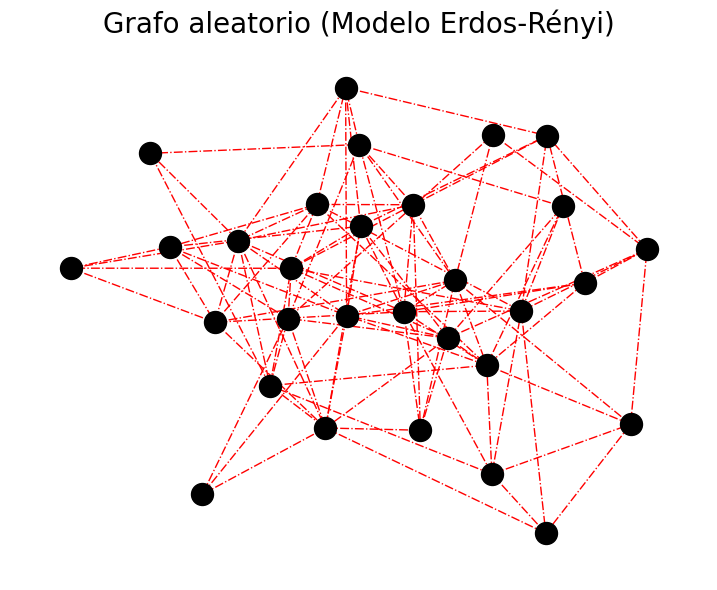

---

In [10]:
######################################
# ERDOS-RENYI
######################################

# Usamos la función "erdos_renyi_graph" para generar un grafo basado en el modelo Eros-Rényi
e_r = nx.erdos_renyi_graph(30, 0.25, seed = 50)   # 30 nodos | Probabilidad de arista del 25%

# Mostramos el grafo por pantalla
plt.figure(figsize=(9,7))
plt.title('Grafo aleatorio (Modelo Erdos-Rényi)', fontsize = 20)

# Vamos a calcular la posiciones (nodos)
posiciones = nx.spring_layout(e_r, seed = 18)

# Dibujamos los nodos y arsitas
nx.draw_networkx_nodes(e_r, posiciones, node_color = 'black', node_size = 250)
nx.draw_networkx_edges(e_r, posiciones, edge_color = 'red', style = '-.')

plt.axis('off')
plt.show()
display(Markdown("---"))

**BARABASI-ALBERT**

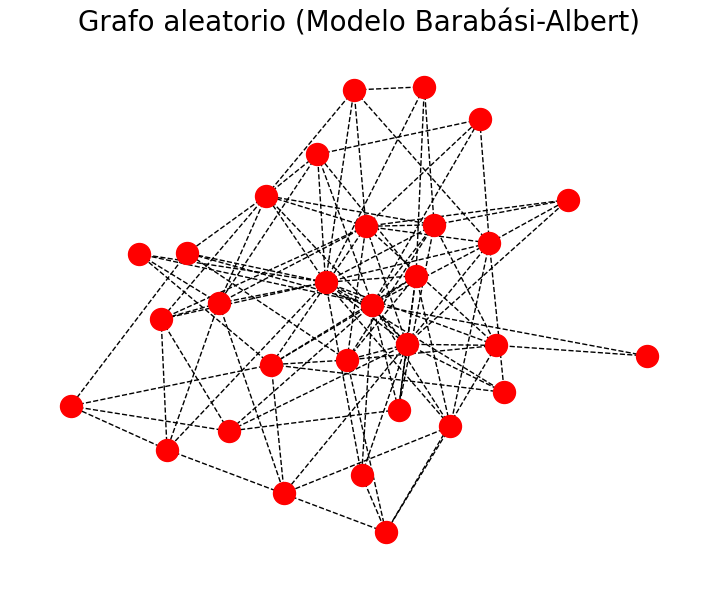

---

In [11]:
######################################
# BARABASI-ALBERT
######################################

# Usamos la función "barabasi_albert_graph" para generar un grafo basado en el modelo Barabási-Albert
b_a = nx.barabasi_albert_graph(30, 4, seed=50)   # 30 nodos | Nº enlaces por nodo: 4

# Mostramos el grafo por pantalla
plt.figure(figsize=(9,7))
plt.title('Grafo aleatorio (Modelo Barabási-Albert)', fontsize = 20)

# Vamos a calcular la posiciones (nodos)
posiciones = nx.spring_layout(b_a, seed = 18)

# Dibujamos los nodos y arsitas
nx.draw_networkx_nodes(b_a, posiciones, node_color = 'red', node_size = 250)
nx.draw_networkx_edges(b_a, posiciones, edge_color = 'black', style = '--')

plt.axis('off')
plt.show()
display(Markdown("---"))

**WATTS-STROGATZ**

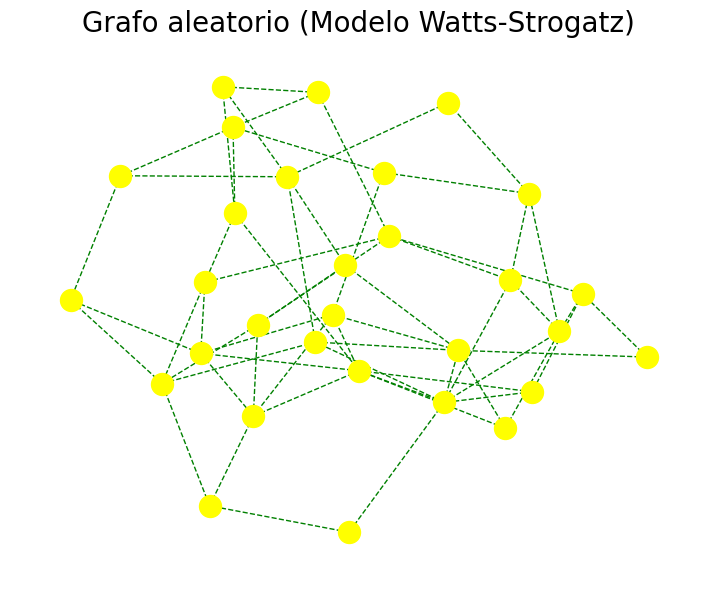

---

In [12]:
######################################
# WATTS-STROGATZ
######################################

# Usamos la función "watts_strogatz_graph" para generar un grafo basado en el modelo Watts-Strogatz
w_s = nx.watts_strogatz_graph(30, 4, 0.5, seed = 50)   # 30 nodos | Grado medio | Probabilidad reconexión

# Mostramos el grafo por pantalla
plt.figure(figsize=(9,7))
plt.title('Grafo aleatorio (Modelo Watts-Strogatz)', fontsize = 20)

# Vamos a calcular la posiciones (nodos)
posiciones = nx.spring_layout(w_s, seed = 18)

# Dibujamos los nodos y arsitas
nx.draw_networkx_nodes(w_s, posiciones, node_color = 'yellow', node_size = 250)
nx.draw_networkx_edges(w_s, posiciones, edge_color = 'green', style = '--')

plt.axis('off')
plt.show()
display(Markdown("---"))

**Árbol**

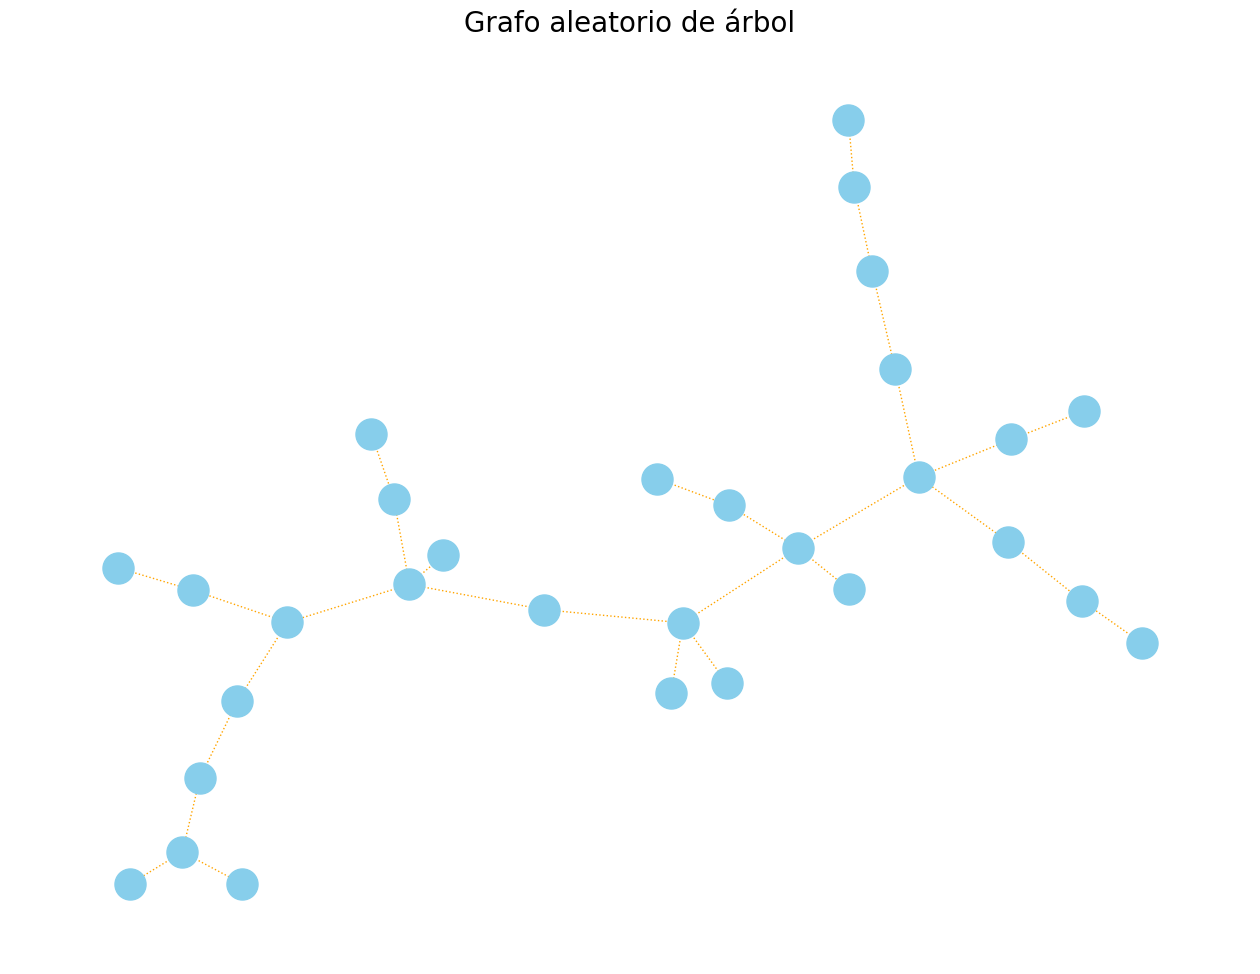

---

In [13]:
######################################
# TREE
######################################

# Usamos la función "random_tree" para generar un grafo de árbol
t = nx.random_tree(30, seed=50)   # 30 nodos

# Mostramos el grafo por pantalla
plt.figure(figsize=(16,12))
plt.title('Grafo aleatorio de árbol', fontsize = 20)

# Vamos a calcular la posiciones (nodos)
posiciones = nx.spring_layout(t, seed = 18)

# Dibujamos los nodos y arsitas
nx.draw_networkx_nodes(t, posiciones, node_color = 'skyblue', node_size = 500)
nx.draw_networkx_edges(t, posiciones, edge_color = 'orange', style = ':')

plt.axis('off')
plt.show()
display(Markdown("---"))

**STOCHASTIC BLOCK MODEL**

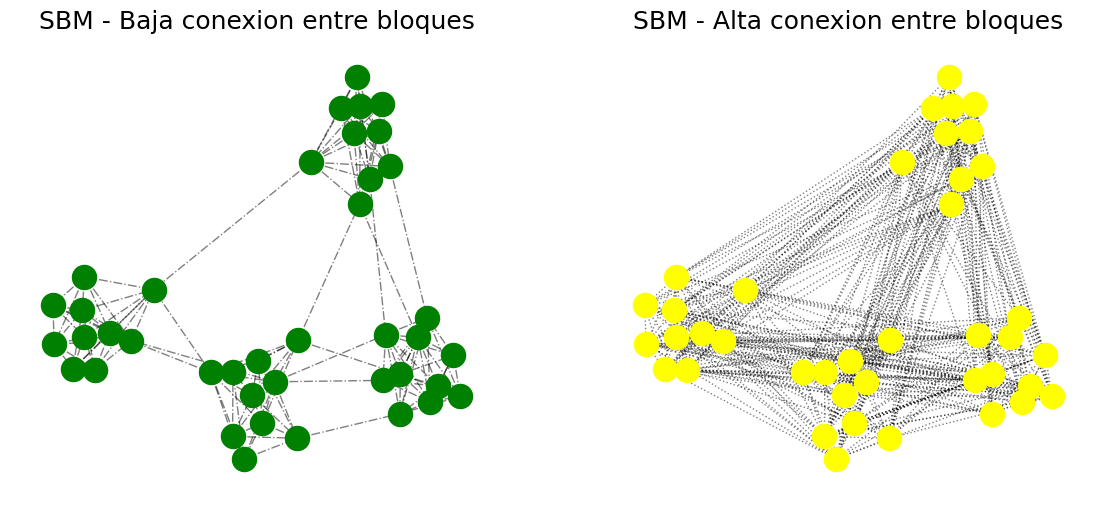

---

In [15]:
######################################
# STOCHASTIC_BLOCK_MODEL (SBM)
######################################
# Creamos 4 bloques de 10 nodos cada uno
sizes = [10, 10, 10, 10]

# Definimos las matrices de probabilidad:
    # Baja: Probabilidad baja conexión entre bloques distintos
    # Alta: Probabilidad alta conexión entre bloques distintos
baja = [
    [0.8, 0.02, 0.02, 0.02],
    [0.02, 0.8, 0.02, 0.02],
    [0.02, 0.02, 0.8, 0.02],
    [0.02, 0.02, 0.02, 0.8]
]
alta = [
    [0.8, 0.4, 0.4, 0.4],
    [0.4, 0.8, 0.4, 0.4],
    [0.4, 0.4, 0.8, 0.4],
    [0.4, 0.4, 0.4, 0.8]
]
# Definimos la semilla para que los resultados sean reproducibles
seed = 96

# Creamos los 2 grafos (SBM)
G1 = nx.stochastic_block_model(sizes, baja, seed=seed)  # El primero -> Probabilidad alta
G2 = nx.stochastic_block_model(sizes, alta, seed=seed)  # El segundo -> Probabilidad baja

# Calculamos las posiciones (las mismas para los dos grafos)
pos = nx.spring_layout(G1, seed=seed)
# Vamos a dividir los dos grafos en una misma figura
fig, axes = plt.subplots(1, 2, figsize=(14,6))

# Primer grafo
#--------------#
# Definimos título
axes[0].set_title('SBM - Baja conexion entre bloques', fontsize = 18)  
nx.draw_networkx_nodes(G1, pos, node_size=300, node_color='green', ax=axes[0])  # Dibujamos los nodos
nx.draw_networkx_edges(G1, pos, width=1.0, alpha=0.5, edge_color='black', style='-.', ax=axes[0]) # Dibujamos las aristas
axes[0].axis('off')

# Segundo grafo
#---------------#
# Definimos título
axes[1].set_title('SBM - Alta conexion entre bloques', fontsize = 18)
nx.draw_networkx_nodes(G2, pos, node_size=300, node_color= 'yellow', ax=axes[1])         # Dibujamos los nodos
nx.draw_networkx_edges(G2, pos, width=1.0, alpha=0.5, style=':', ax=axes[1])  # Dibujamos las arsitas
axes[1].axis('off')

# Mostramos el resultado por pantalla
plt.show()

display(Markdown(f'---'))